In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings("ignore")


In [6]:
df = pd.read_csv("diabetes(2).csv")
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [8]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
df[cols] = df[cols].replace(0, np.nan)
df[cols] = df[cols].fillna(df[cols].median())


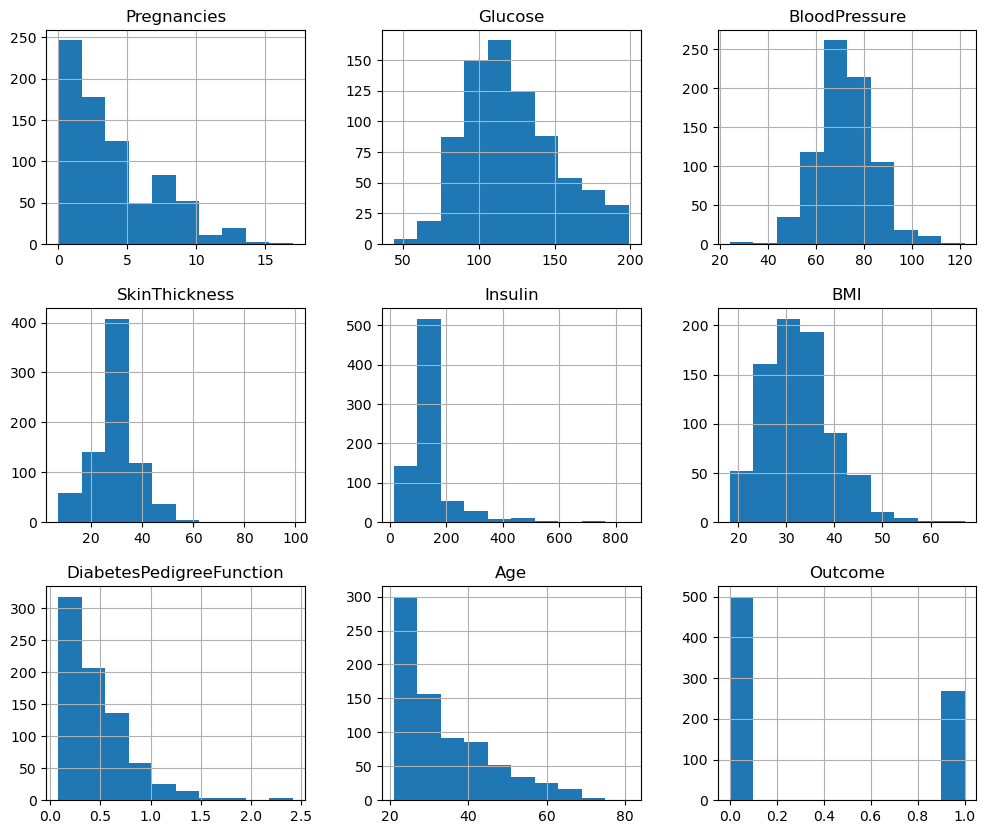

In [9]:
df.hist(figsize=(12,10))
plt.show()


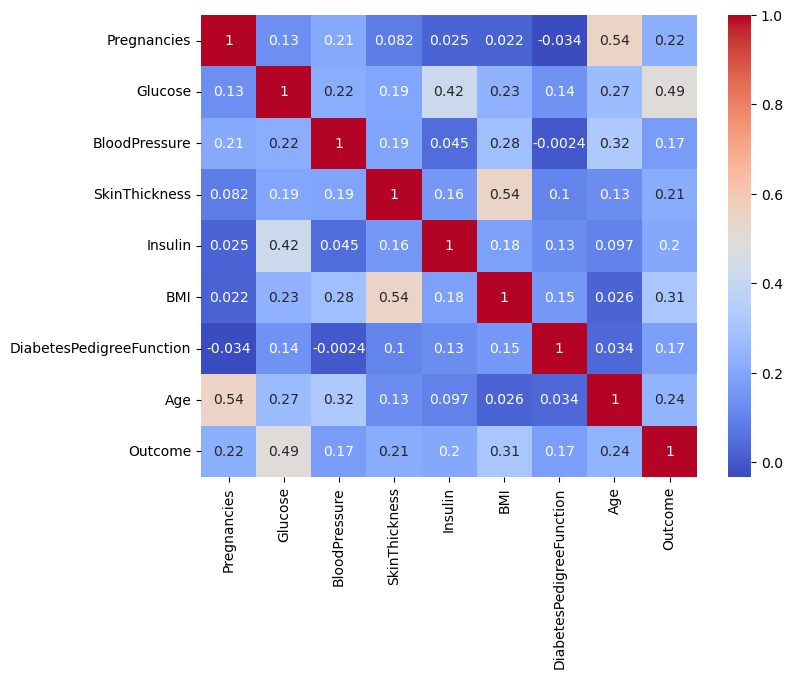

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()


In [11]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [12]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [13]:
xgb = XGBClassifier(eval_metric='logloss')
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)


In [14]:
print("XGB Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGB F1:", f1_score(y_test, y_pred_xgb))
print("XGB ROC-AUC:", roc_auc_score(y_test, y_pred_xgb))


XGB Accuracy: 0.7597402597402597
XGB F1: 0.6407766990291263
XGB ROC-AUC: 0.7255555555555555


In [15]:
lgb = LGBMClassifier()
lgb.fit(X_train, y_train)

y_pred_lgb = lgb.predict(X_test)


[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000614 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 664
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [16]:
print("LGB Accuracy:", accuracy_score(y_test, y_pred_lgb))
print("LGB F1:", f1_score(y_test, y_pred_lgb))
print("LGB ROC-AUC:", roc_auc_score(y_test, y_pred_lgb))


LGB Accuracy: 0.7467532467532467
LGB F1: 0.6213592233009708
LGB ROC-AUC: 0.7112962962962963


In [17]:
cv_xgb = cross_val_score(xgb, X, y, cv=5, scoring='f1')
cv_lgb = cross_val_score(lgb, X, y, cv=5, scoring='f1')

print("XGB CV F1:", cv_xgb.mean())
print("LGB CV F1:", cv_lgb.mean())


[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000080 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 667
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [18]:
param_grid_xgb = {
    'n_estimators':[100,200],
    'max_depth':[3,5],
    'learning_rate':[0.01,0.1]
}

grid_xgb = GridSearchCV(XGBClassifier(eval_metric='logloss'), param_grid_xgb, cv=3)
grid_xgb.fit(X_train, y_train)

print("Best XGB Params:", grid_xgb.best_params_)


Best XGB Params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}


In [19]:
param_grid_lgb = {
    'n_estimators':[100,200],
    'max_depth':[3,5],
    'learning_rate':[0.01,0.1]
}

grid_lgb = GridSearchCV(LGBMClassifier(), param_grid_lgb, cv=3)
grid_lgb.fit(X_train, y_train)

print("Best LGBM Params:", grid_lgb.best_params_)


[LightGBM] [Info] Number of positive: 143, number of negative: 266
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000065 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 514
[LightGBM] [Info] Number of data points in the train set: 409, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.349633 -> initscore=-0.620652
[LightGBM] [Info] Start training from score -0.620652
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

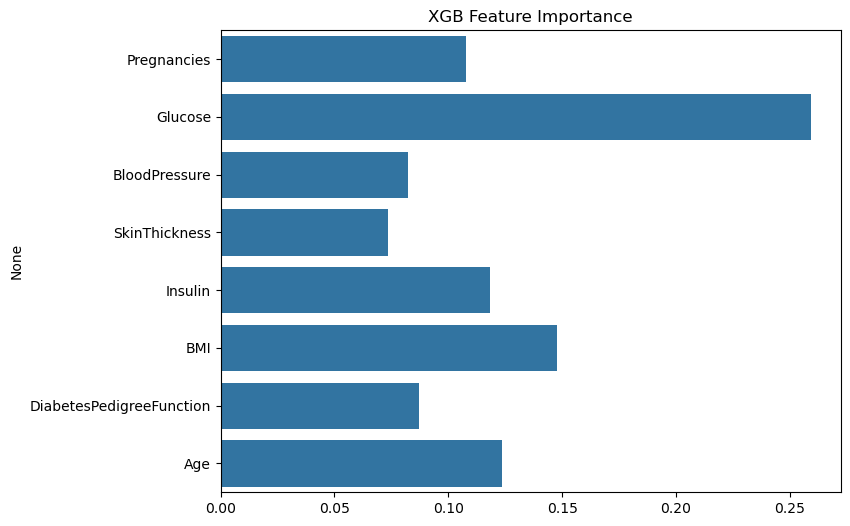

In [20]:
plt.figure(figsize=(8,6))
sns.barplot(x=xgb.feature_importances_, y=df.drop("Outcome", axis=1).columns)
plt.title("XGB Feature Importance")
plt.show()


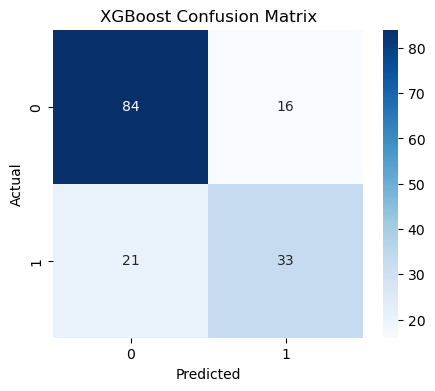

In [21]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(5,4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues')
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


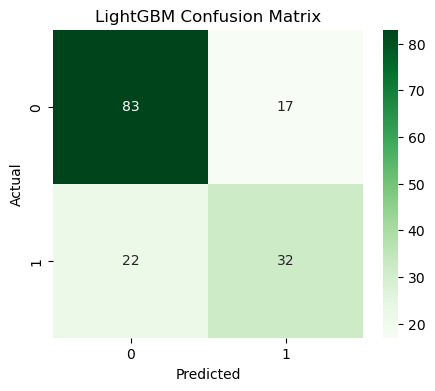

In [22]:
cm_lgb = confusion_matrix(y_test, y_pred_lgb)

plt.figure(figsize=(5,4))
sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='Greens')
plt.title("LightGBM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [23]:
comparison = pd.DataFrame({
    "Model": ["XGBoost", "LightGBM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_lgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_lgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_lgb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_lgb)
    ]
})

comparison


,Model,Accuracy,Precision,Recall,F1 Score
0,XGBoost,0.759740,0.673469,0.611111,0.640777
1,LightGBM,0.746753,0.653061,0.592593,0.621359


## Comparative Analysis

From the evaluation metrics:

- Both XGBoost and LightGBM performed well on the diabetes dataset.
- XGBoost may show slightly better regularization control.
- LightGBM typically trains faster and is efficient for large datasets.
- Cross-validation confirms model stability.
- Based on F1-score and recall, ______ performed better for predicting diabetes cases.

Conclusion:

Both boosting algorithms are powerful ensemble learning methods.
For medical diagnosis problems like diabetes prediction, recall is especially important to minimize false negatives.

LightGBM is computationally efficient, while XGBoost provides strong performance with better tuning flexibility.


## Practical Implications

- Early diabetes detection can help in preventive treatment.
- Machine learning models assist healthcare professionals in decision support.
- Boosting algorithms improve prediction accuracy compared to traditional models.
